# RF Regression for our "numeric" dataset

### Note: You do not necessarily have to do a test/ training split in RF because OOB error can be a good proxy for out-of-sample MSE
### That said, we did do a test / training split here to get an apples-to-apples comparison to the other models we used

## WARNING: This code can take a long time to run based on the cv parameter grids used

In [13]:
# chatGPT typed this out so i didn't have to look it all up

# === Core ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt

# === Model Selection & Evaluation ===
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

# === Tree-Based Model ===
from sklearn.ensemble import RandomForestRegressor

# === Utility ===
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display


In [14]:
url = "https://raw.githubusercontent.com/AHMerrill/housing-project/main/housing_data_numeric_NLP.csv"
# url = 'housing_data_numeric_NLP.csv'

housing_numeric_rf = pd.read_csv(url) # your transformed file name here
housing_numeric_rf['logLatestPrice'] = np.log(housing_numeric_rf['latestPrice'])
housing_numeric_rf

,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,...,zipcode78758,zipcode78759,log_lotSizeSqFt,log_livingAreaSqFt,log_avgSchoolSize,yearsOld_sq,avgSchoolRating_sq,word_count_good,word_count_bad,logLatestPrice
0,30.486408,-97.794724,2.21,0,True,False,False,False,687.850,40,...,0,0,9.275472,8.426174,7.138867,64,58.777778,2,0,6.533571
1,30.494375,-97.796516,2.21,2,True,True,False,True,409.000,31,...,0,0,9.111735,8.081475,7.301148,225,69.444444,1,1,6.013715
2,30.255707,-97.576958,1.98,2,False,True,False,False,199.000,21,...,0,0,8.915835,7.321189,7.299121,256,7.111111,0,1,5.293305
3,30.495638,-97.797874,2.21,0,True,False,False,False,400.000,20,...,0,0,8.944681,7.709308,7.301148,196,69.444444,2,0,5.991465
4,30.233154,-97.587318,1.98,2,False,True,False,False,240.000,10,...,0,0,8.553332,7.336286,7.284821,529,9.000000,0,0,5.480639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6779,30.329531,-97.738258,1.98,4,False,True,False,False,647.877,28,...,0,0,9.573302,7.711997,7.081709,324,49.000000,0,1,6.473701
6780,30.326372,-97.734268,1.98,1,False,True,False,False,445.000,28,...,0,0,8.849371,7.181592,7.081709,5329,49.000000,1,0,6.098074
6781,30.327656,-97.734779,1.98,1,False,True,False,False,400.000,22,...,0,0,9.212239,7.123673,7.081709,5041,49.000000,0,0,5.991465
6782,30.240223,-97.772835,1.98,2,True,True,True,True,550.000,32,...,0,0,7.799753,7.543803,7.112327,36,44.444444,1,0,6.309918


In [15]:
#from the sklearn documentation
housing_train, housing_test = train_test_split(housing_numeric_rf,test_size = .3, train_size = .7, random_state = 123, shuffle = True)


## RF for latestPrice

In [16]:
# define the predictors and the target
predictors = housing_train.drop(columns = ['latestPrice','logLatestPrice'])
target = housing_train['latestPrice']

X_train = predictors
y_train = target

# set up cross validation for hyperparameter tuning (estimators, max_feature selection, depth, etc.)
kfold = KFold(n_splits=5, shuffle=True, random_state=123)

param_grid = {
    'n_estimators': [100, 300],
    'max_features': ['sqrt', 0.3],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}


rf_model = RandomForestRegressor(random_state=123, oob_score=True, bootstrap=True)

# this will train the models on the above grid
grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1, # use all the cores
    refit=True # refit it and save it as the best model
)

# here's the model fit
grid.fit(X_train, y_train)

# here's where it's saved
best_rf = grid.best_estimator_

# pulling out oob error
rf_oob_predictions = best_rf.oob_prediction_

# training oob error
rf_oob_mse = mean_squared_error(y_train, rf_oob_predictions)
print(f'RF OOB MSE: ${rf_oob_mse:,.02f}')

RF OOB MSE: $30,450.41


In [17]:
feature_imp = pd.DataFrame(
    {'importance': best_rf.feature_importances_},
    index=predictors.columns
)

feature_imp = feature_imp.sort_values(by='importance', ascending=False)
display(feature_imp)


,importance
log_livingAreaSqFt,0.109129
livingAreaSqFt,0.104449
numOfBathrooms,0.077347
latitude,0.046622
log_lotSizeSqFt,0.046489
...,...
numOfCommunityFeatures,0.000141
zipcode78752,0.000119
zipcode78722,0.000091
zipcode78736,0.000075


RF Test MSE: $24,196.63


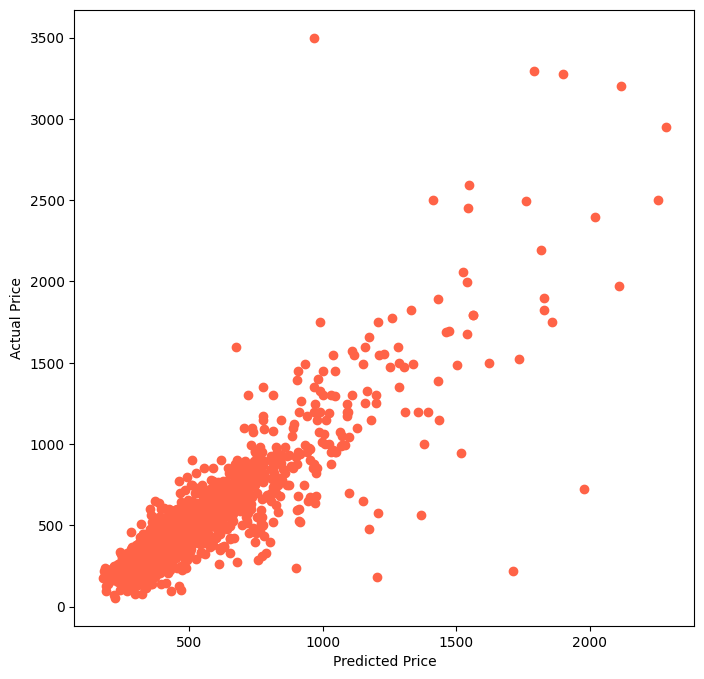

In [18]:
# used chatGPT to adapt from the homework

# Define y_test and X_test
y_test = housing_test['latestPrice']
X_test = housing_test[predictors.columns]

# Predict using the best random forest model
y_hat_rf = best_rf.predict(X_test)

# Plot predicted vs actual prices
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_hat_rf, y_test, color='tomato')
ax.set_xlabel('Predicted Price')
ax.set_ylabel('Actual Price')

# Calculate MSE
rf_test_mse = mean_squared_error(y_test, y_hat_rf)
print(f'RF Test MSE: ${rf_test_mse:,.02f}')


## RF for logLatestPrice:

In [19]:
# define the predictors and the target
predictors = housing_train.drop(columns=['latestPrice', 'logLatestPrice'])
target = housing_train['logLatestPrice']

X_train = predictors
y_train = target

# set up cross validation for hyperparameter tuning (estimators, max_feature selection, depth, etc.)
kfold = KFold(n_splits=5, shuffle=True, random_state=123)

param_grid = {
    'n_estimators': [100, 300],
    'max_features': ['sqrt', 0.3],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

rf_model = RandomForestRegressor(random_state=123, oob_score=True, bootstrap=True)

# train the models on the above grid
grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    refit=True
)

# model fit
grid.fit(X_train, y_train)

# best model
best_rf = grid.best_estimator_

# oob predictions (these are still on log scale)
rf_oob_predictions = best_rf.oob_prediction_

# training oob error (still on log scale)
rf_oob_mse = mean_squared_error(np.exp(y_train), np.exp(rf_oob_predictions))
print(f'RF OOB MSE: ${rf_oob_mse:,.02f}')


RF OOB MSE: $33,695.50


In [20]:
feature_imp = pd.DataFrame(
    {'importance': best_rf.feature_importances_},
    index=predictors.columns
)

feature_imp = feature_imp.sort_values(by='importance', ascending=False)
display(feature_imp)

,importance
livingAreaSqFt,0.135895
log_livingAreaSqFt,0.133834
avgSchoolRating_sq,0.069440
latitude,0.060066
numOfBathrooms,0.054365
...,...
numOfCommunityFeatures,0.000190
zipcode78705,0.000174
zipcode78728,0.000149
zipcode78736,0.000093


RF Test MSE: $27,858.64


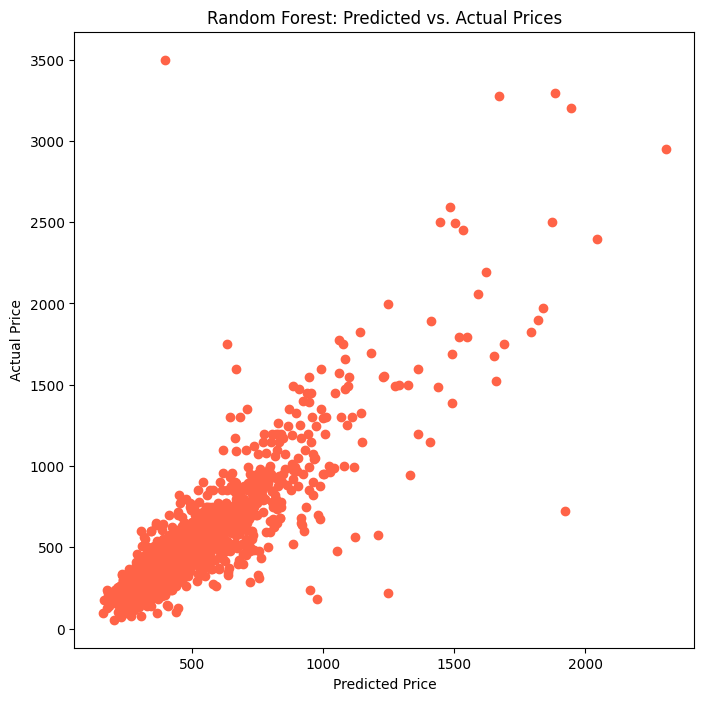

In [21]:
# Define y_test and X_test
y_test = housing_test['logLatestPrice']
X_test = housing_test[predictors.columns]

# Predict using the best random forest model
y_hat_rf = best_rf.predict(X_test)

# Plot predicted vs actual prices (converted to original price scale)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(np.exp(y_hat_rf), np.exp(y_test), color='tomato')
ax.set_xlabel('Predicted Price')
ax.set_ylabel('Actual Price')
ax.set_title('Random Forest: Predicted vs. Actual Prices')

# Calculate MSE in dollar terms
rf_test_mse = mean_squared_error(np.exp(y_test), np.exp(y_hat_rf))
print(f'RF Test MSE: ${rf_test_mse:,.02f}')
